# Example of usage ImageTextCleaner transformer for process bad quility scanned PDF document

## Install spark-ocr python packge
Need specify path to `spark-ocr-assembly-[version].jar` or `secret`

In [1]:
secret = ""
license = ""
aws_access_key = ""
aws_secret_key = ""
version = secret.split("-")[0]
spark_ocr_jar_path = "../../target/scala-2.12"

In [2]:
# install from PYPI using secret
#%pip install spark-ocr==$version+spark32 --extra-index-url=https://pypi.johnsnowlabs.com/$secret --upgrade

In [3]:
#or install from local path
#%pip install ../../python/dist/spark-ocr-4.0.0+spark32.tar.gz

## Initialization of spark session

In [4]:
from pyspark.sql import SparkSession
from sparkocr import start
import sys
import os

if license:
    os.environ['JSL_OCR_LICENSE'] = license


if aws_access_key:
    os.environ['AWS_ACCESS_KEY'] = aws_access_key
    os.environ['AWS_SECRET_ACCESS_KEY'] = aws_secret_key

spark = start(secret=secret, jar_path=spark_ocr_jar_path)
spark

Spark version: 3.4.0
Spark NLP version: 6.4.2-rc2
Spark NLP for Healthcare version: 6.4.1
Spark OCR version: 6.4.2



## Import OCR transformers

In [5]:
from pyspark.ml import PipelineModel

from sparkocr.transformers import *
from sparkocr.enums import *
from sparkocr.utils import *

## Read Pdf as binary file and display it


    Image #0:
    Origin: file:/home/jose/spark-ocr/workshop/jupyter/data/pdfs/noised.pdf
    Resolution: 300 dpi
    Width: 2479 px
    Height: 3508 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


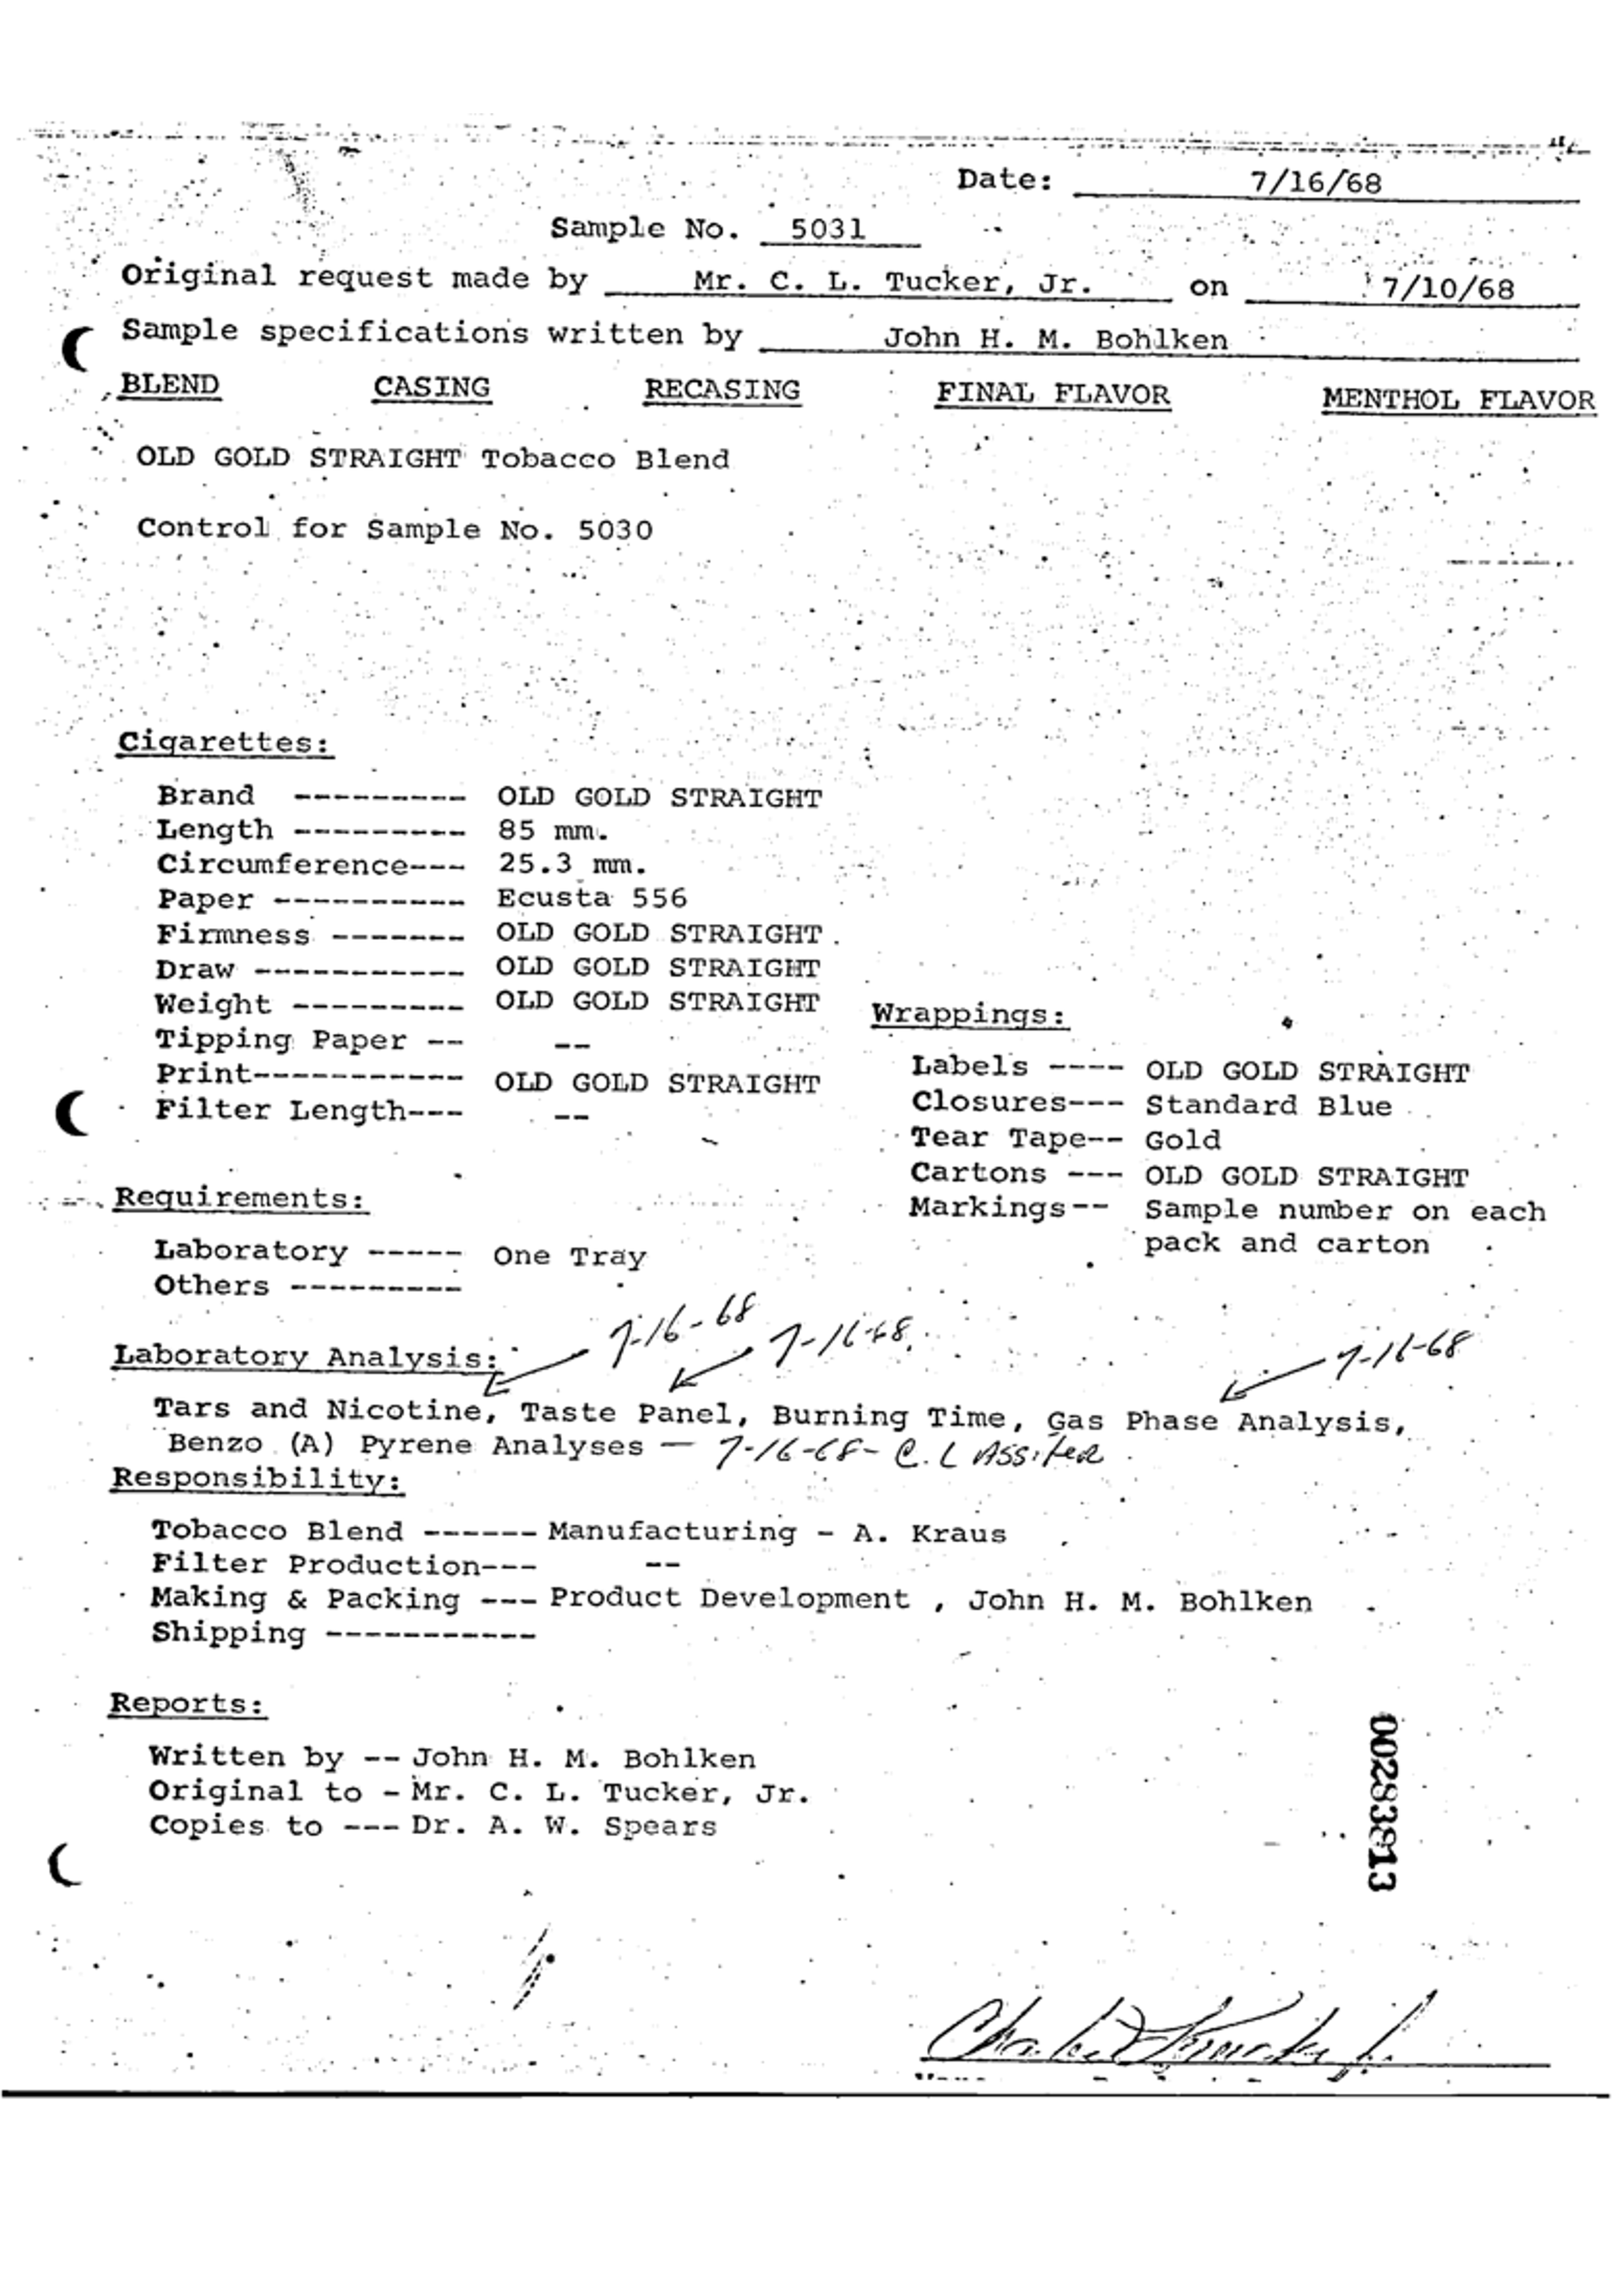

In [6]:
import pkg_resources
pdf_example ='data/pdfs/noised.pdf'
pdf_example_df = spark.read.format("binaryFile").load(pdf_example).cache()

display_pdf(pdf_example_df)

## Define OCR transformers and pipeline

In [7]:
pdf_to_image = PdfToImage() \
    .setInputCol("content") \
    .setOutputCol("image") \
    .setResolution(300)

ocr = ImageToText() \
    .setInputCol("image") \
    .setOutputCol("text") \
    .setConfidenceThreshold(70) \
    .setIgnoreResolution(False)

cleaner = ImageTextCleaner \
    .pretrained("text_cleaner_v1", "en", "clinical/ocr") \
    .setInputCol("image") \
    .setOutputCol("corrected_image") \
    .setMedianBlur(0) \
    .setSizeThreshold(10) \
    .setTextThreshold(0.3) \
    .setLinkThreshold(0.2) \
    .setBinarize(False)

ocr_corrected = ImageToText() \
    .setInputCol("corrected_image") \
    .setOutputCol("corrected_text") \
    .setConfidenceThreshold(70) \
    .setIgnoreResolution(False)

pipeline = PipelineModel(stages=[
    pdf_to_image,
    ocr,
    cleaner,
    ocr_corrected
])


text_cleaner_v1 download started this may take some time.
Approximate size to download 73.5 MB


## Display results without correction

In [8]:
results = pipeline.transform(pdf_example_df).cache()

print(f"Detected text:\n{results.select('text').collect()[0].text}")

Detected text:
 

 

 

Sample specifications written by

 

~ , BLEND CASING RECASING
= OLD GOLD STRAIGHT Tobacco Blend

Control for Sample No. 5030

 

 

 

 

 

MENTHOL FLAVOR

 

Tars and Nicotine, Taste Panel, Burning Time, Gas Phase Analysis,

“Benzo (A) Pyrene Analyses —

Written by -- John H. M. Bohlken
Original to -Mr. C. L. Tucker, dr.
Copies to ---Dr. A. W. Spears

C

 

 



## Dispaly corrected image


    Image #0:
    Origin: file:/home/jose/spark-ocr/workshop/jupyter/data/pdfs/noised.pdf
    Resolution: 300 dpi
    Width: 2479 px
    Height: 3508 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


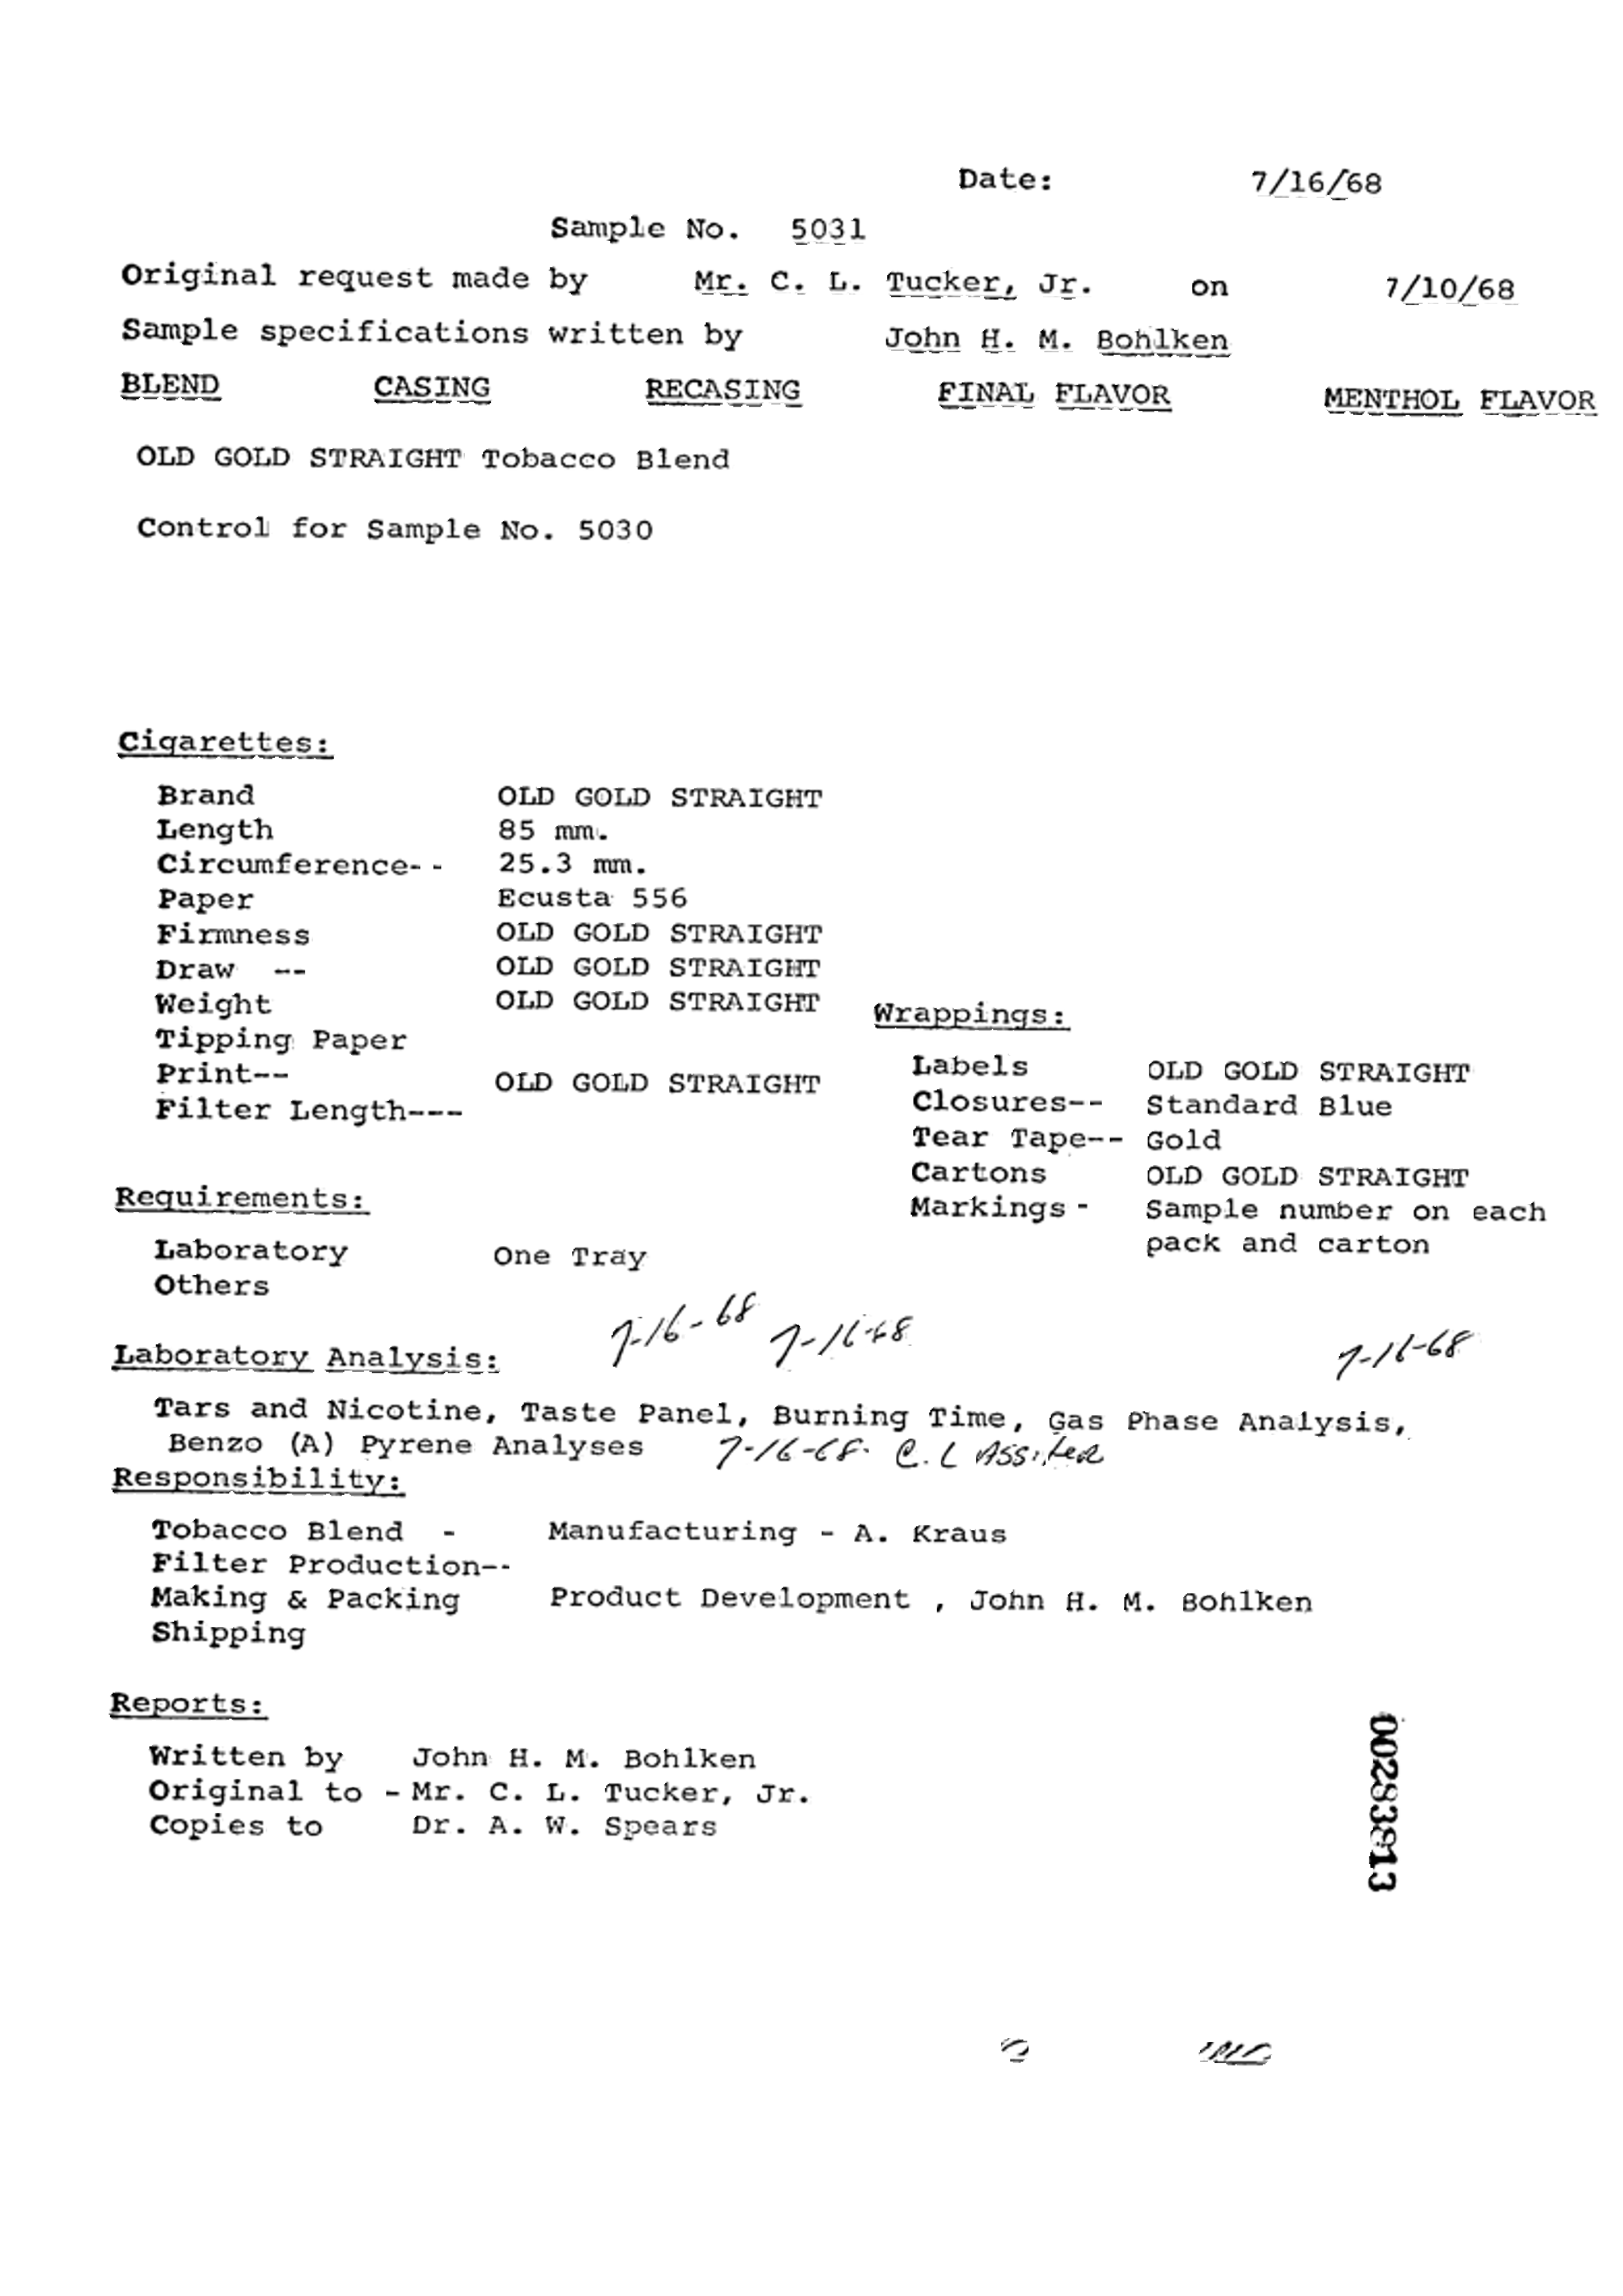

In [9]:
display_images(results, "corrected_image")

## Display recognized text from the corrected image

In [10]:
print(f"Detected text from corrected image:\n{results.select('corrected_text').collect()[0].corrected_text}")

Detected text from corrected image:
Date: 7/16/68
Sample No. 5031

Original request made by Mr. C. L. Tucker, Jr. on 7/10/68
Sample specifications written by John H. M. Bohlken
BLEND CASING RECASING FINAL FLAVOR MENTHOL FLAVOR

OLD GOLD STRAIGHT Tobacco Blend

Control for Sample No. 5030

 

 

Cigarettes:
Brand OLD GOLD STRAIGHT
Length 85 mm.
Circumference-- 25.3 mn.
Paper Ecusta 556
Firmness OLD GOLD STRAIGHT
Draw -- OLD GOLD STRAIGHT
Weight OLD GOLD STRAIGHT Wrappings:
Tipping Paper
Labels OLD GOLD STRAIGHT
Print--
Filter Length--- OLD GOLD STRAIGHT Closures-- Standard Blue
Tear Tape-- Gold
Cartons OLD GOLD STRAIGHT
Reguirements: Markings - Sample number on each
Laboratory One Tray pack and carton
Others
q- /b- bf q-/t 46 (CE
Laboratory Analysis: 77

 

 

Tars and Nicotine, Taste Panel, Burning Time, Gas Phase Analysis,
Benzo (A) Pyrene Analyses 7 -/E-CF> OC 55: Fed
Responsibility:

 

Tobacco Blend - Manufacturing - A. Kraus

Filter Production--
Making & Packing Product Developmen

## Dispaly both image

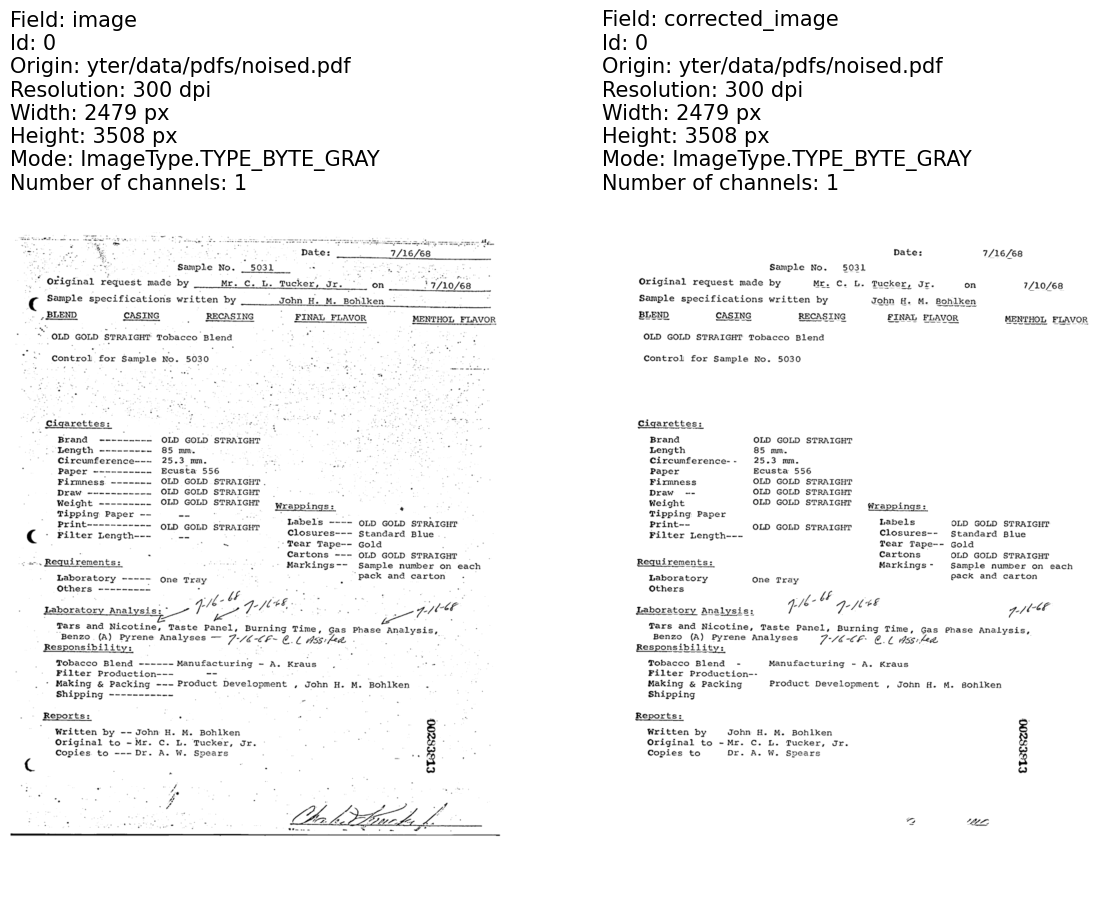

In [11]:
display_images_horizontal(results, "image,corrected_image")